# Optimal Clustering Analysis

In [2]:
import os, sys
import polars as pl
import numpy as np
from db_robust_clust.plots import clustering_MDS_plot_one_method
from robust_mixed_dist.quantitative import euclidean_dist_matrix
from sklearn.manifold import MDS
import joblib

pl.Config.set_fmt_str_lengths(5000)

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')
sys.path.append(project_path)

from src.utils.clustering_analysis_utils import (
    plot_quant_comparison,
    plot_cat_comparison,
    get_medoid_and_knn_by_cluster,
    generate_cluster_tfidf_visualizations
)

#############################################################################################################################

results_dir = os.path.join(project_path, 'data', 'clustering_analysis_results')
models_dir = os.path.join(project_path, 'models')
optimal_clust_model_I_path = os.path.join(models_dir, 'optimal_model_clust_config_I.joblib')
optimal_clust_model_II_path = os.path.join(models_dir, 'optimal_model_clust_config_II.joblib')
optimal_clust_model_III_path = os.path.join(models_dir, 'optimal_model_clust_config_III.joblib')
processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
os.makedirs(results_dir, exist_ok=True)

#############################################################################################################################

processed_data = pl.read_parquet(processed_data_path)

clust_object_I = joblib.load(optimal_clust_model_I_path)
clust_labels_I = clust_object_I.labels_
processed_data = processed_data.with_columns(
    pl.lit(clust_labels_I).cast(pl.String).alias('clust_label_I')
)

clust_object_II = joblib.load(optimal_clust_model_II_path)
clust_labels_II = clust_object_II.labels_
processed_data = processed_data.with_columns(
    pl.lit(clust_labels_II).cast(pl.String).alias('clust_label_II')
)

clust_object_III = joblib.load(optimal_clust_model_III_path)
clust_labels_III = clust_object_III.labels_
processed_data = processed_data.with_columns(
    pl.lit(clust_labels_III).cast(pl.String).alias('clust_label_III')
)

#############################################################################################################################

QUANT_DISCURSIVE_COMPARISON_COLS = [
    'political_stance_score', 
    'argument_quality_score', 
    'sentiment_score'
]

QUANT_REDDIT_COMPARISON_COLS = [
    'post_score',
    'post_upvote_ratio',
    'post_num_comments',
    'comment_score'
]

CAT_COMPARISON_COLS = [
    'political_stance_score_label',
    'dominant_frame_score_label', 
    'discourse_tone_score_label', 
    'argument_quality_score_label',
    'sentiment_score_label', 
    #########################
    'post_subreddit'
]

CAT_COMPARISON_ORDER = {
    'political_stance_score_label': [
        'Strongly Pro-Palestine',
        'Leaning Pro-Palestine',
        'Neutral / Balanced',
        'Leaning Pro-Israel',
        'Strongly Pro-Israel'
    ],
    'sentiment_score_label': [
        'Very Negative',
        'Moderately Negative',
        'Mildly Negative',
        'Neutral',
        'Mildly Positive',
        'Moderately Positive',
        'Very Positive',
    ],
    'argument_quality_score_label': [
        'Spam / Non-Argument',
        'Pure Reaction', 
        'Bare Opinion',
        'Justified Opinion',
        'Reasoned Argument',
        'Sophisticated Discourse'
    ]
}

KNN_K_TEXTS = 10
KNN_K_PLOTS = 50 

#############################################################################################################################

## Clustering I: SampleDistClustering-KMedoids-PAM - k=4

In [3]:
D, D1, D2, D3 = clust_object_I.dist_output
sample_idx = clust_object_I.sample_idx

plot_file_name = 'optimal_clust_I_mds_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

if not os.path.exists(plot_save_path):

    n_reduced = 2000

    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=123) 

    X_mds = mds.fit_transform(D[:n_reduced, :n_reduced])

    clustering_MDS_plot_one_method(X_mds=X_mds, 
                                y_pred=clust_labels_I[sample_idx[:n_reduced]], 
                                y_true=None, title="MDS visualization of clustering results", 
                                accuracy=None, time=None, 
                                figsize=(8,7), bbox_to_anchor=(1,1), 
                                title_size=13, title_weight='bold', 
                                points_size=45, title_height=1, legend_size=9,
                                save=True, file_name=plot_save_path, format='png'
    )

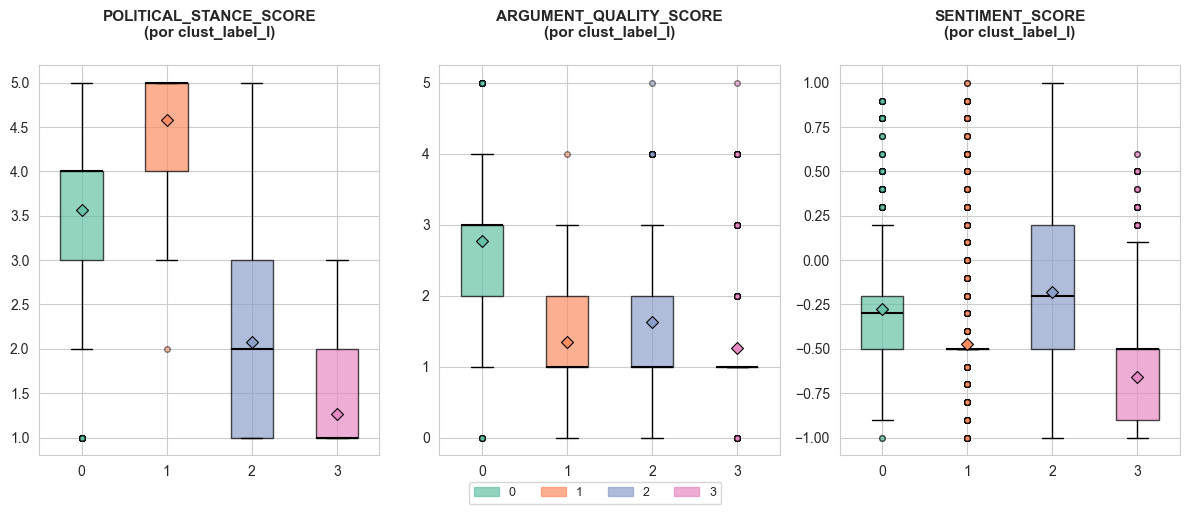

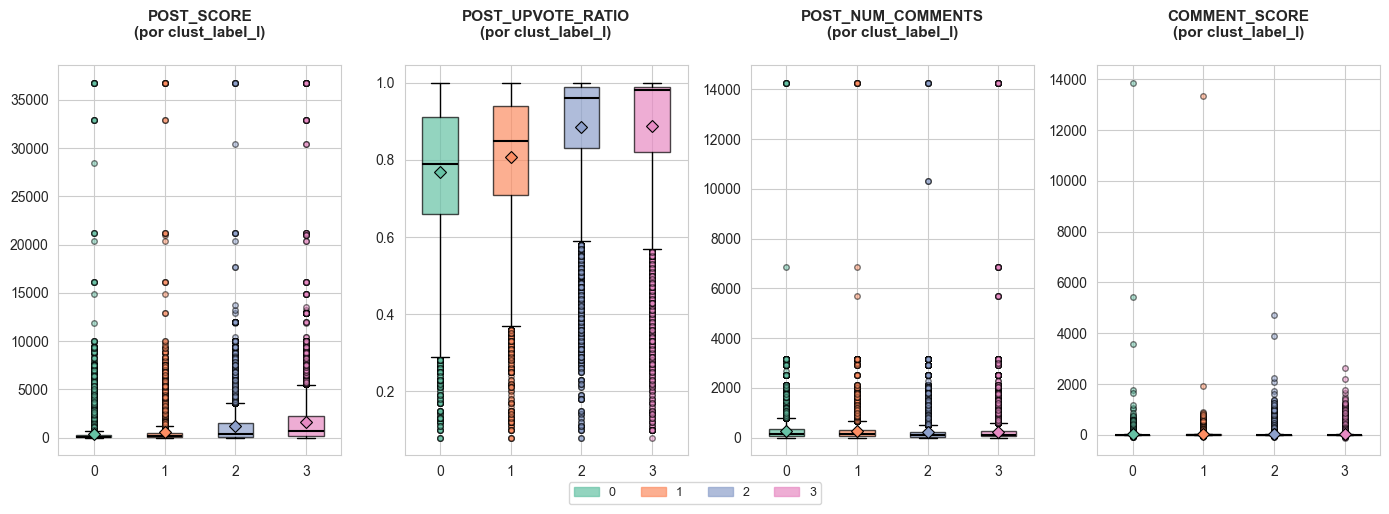

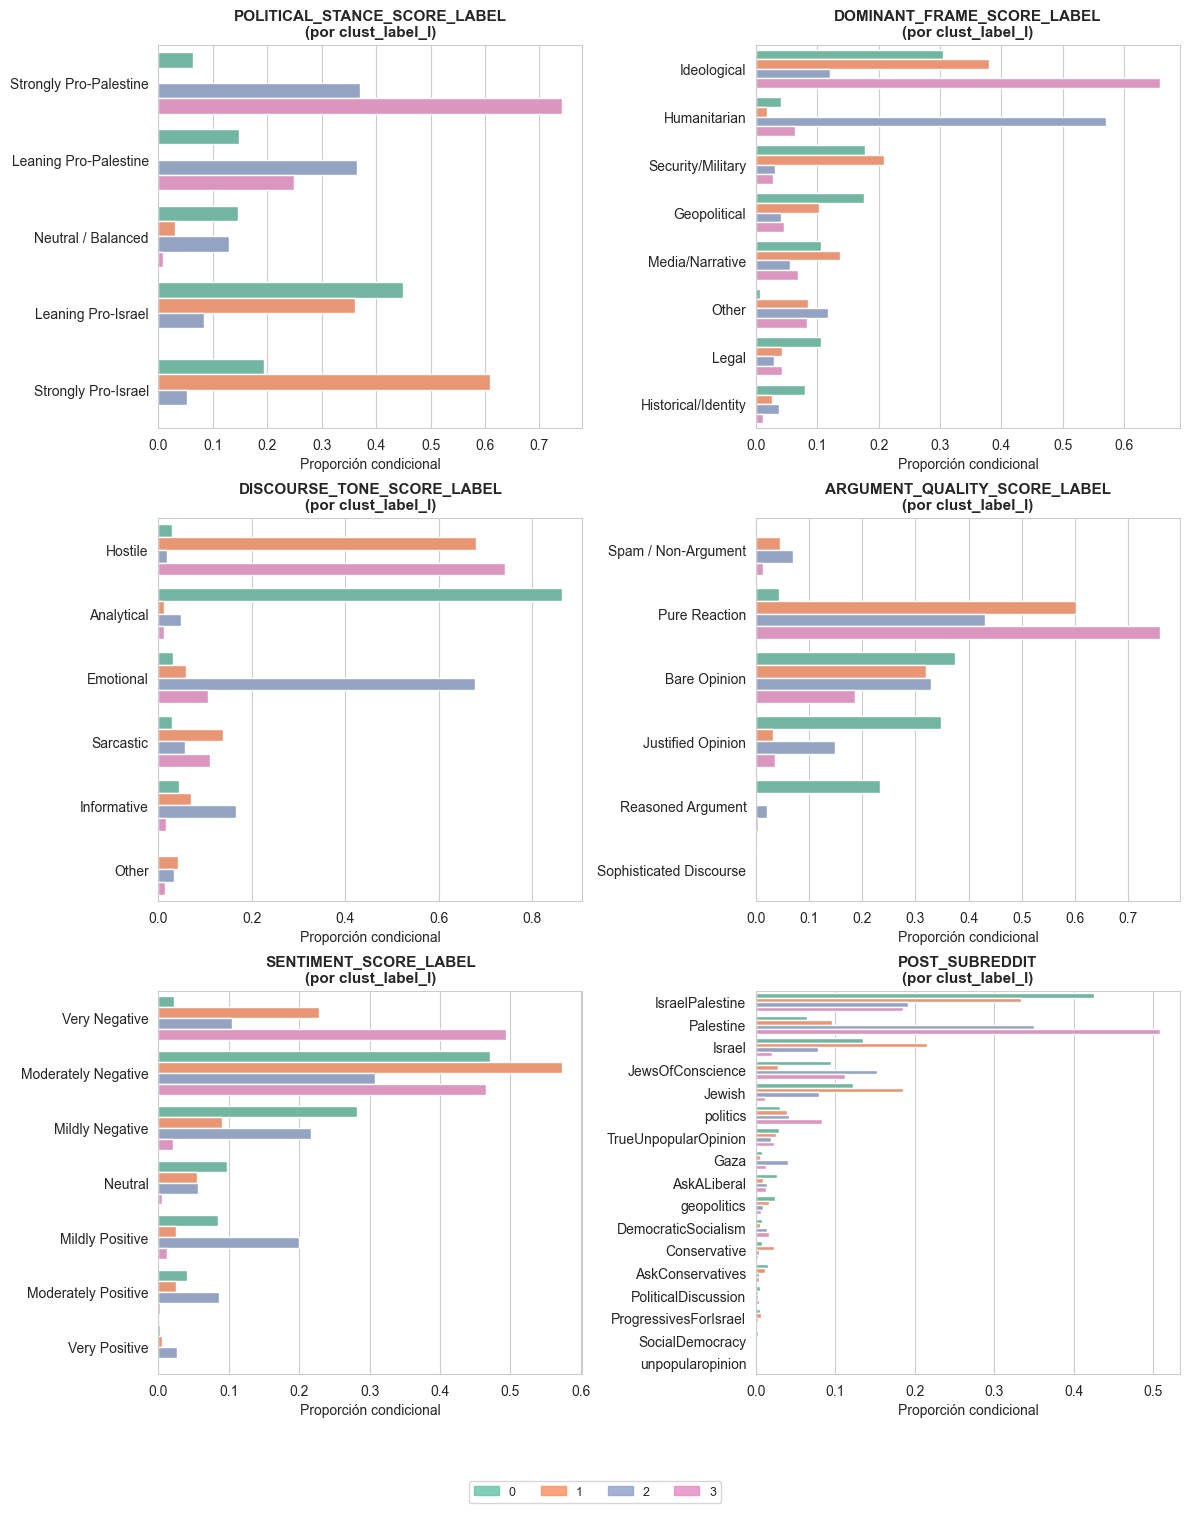

In [4]:
##################################################################################################

plot_file_name = 'optimal_clust_I_quant_discursive_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_quant_comparison(
    figsize=(12, 5),
    df=processed_data,
    comparisons=[
        [col] for col in QUANT_DISCURSIVE_COMPARISON_COLS
    ],
    group_by="clust_label_I",
    showfliers=True,
    title='',
    labelbottom=True,
    xlabel_rotation=0,
    bbox_to_anchor=(0.5, -0.03),
    save_path = plot_save_path
    
)

##################################################################################################

plot_file_name = 'optimal_clust_I_quant_reddit_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_quant_comparison(
    figsize=(14, 5),
    df=processed_data,
    comparisons=[
        [col] for col in QUANT_REDDIT_COMPARISON_COLS
    ],
    group_by="clust_label_I",
    showfliers=True,
    title='',
    labelbottom=True,
    xlabel_rotation=0,
    bbox_to_anchor=(0.5, -0.03),
    save_path = plot_save_path,
    max_cols=4,
)

##################################################################################################

plot_file_name = 'optimal_clust_I_cat_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_cat_comparison(
    df=processed_data, 
    comparisons=[
        [col] for col in CAT_COMPARISON_COLS 
    ], 
    title="",
    bbox_to_anchor=(0.5,-0.01),
    group_by="clust_label_I",
    max_cols=2,
    x_rotation=0,
    orientation='h',
    order=CAT_COMPARISON_ORDER,
    save_path = plot_save_path
)

##################################################################################################

Filtrando dataset mediante índices de medoids y KNN...
Lematizando exclusivamente los comentarios filtrados...
Agrupando comentarios por cluster...
Generando Gráfico de Barras SOTA...


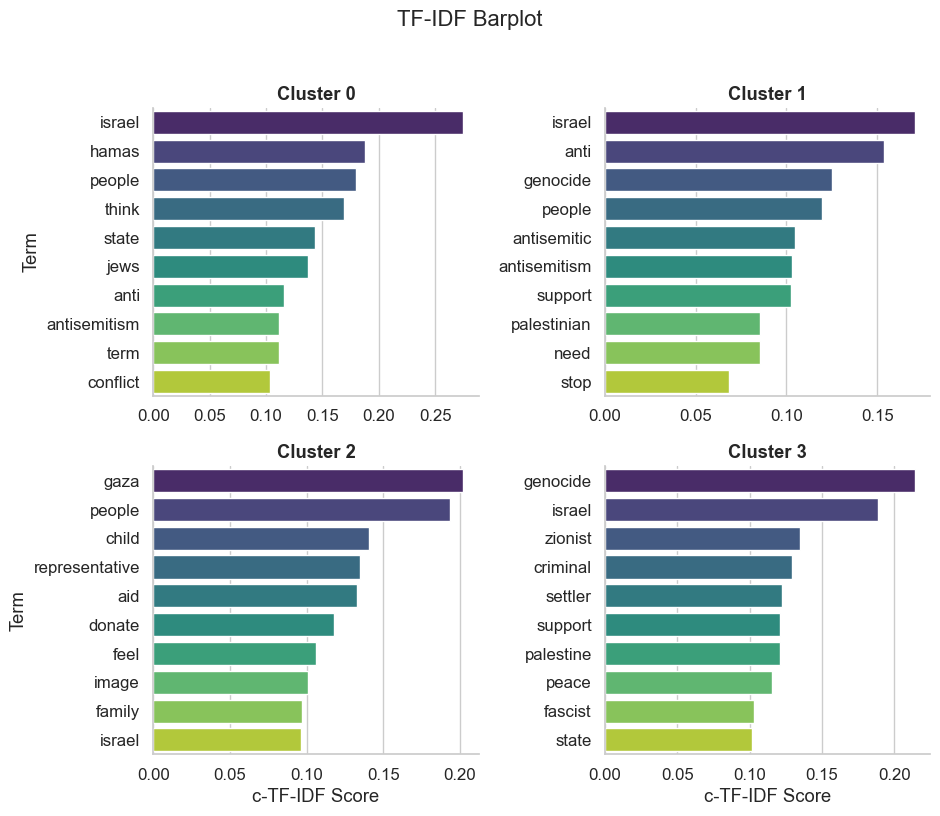

Generando Nubes de Palabras basadas en pesos c-TF-IDF...


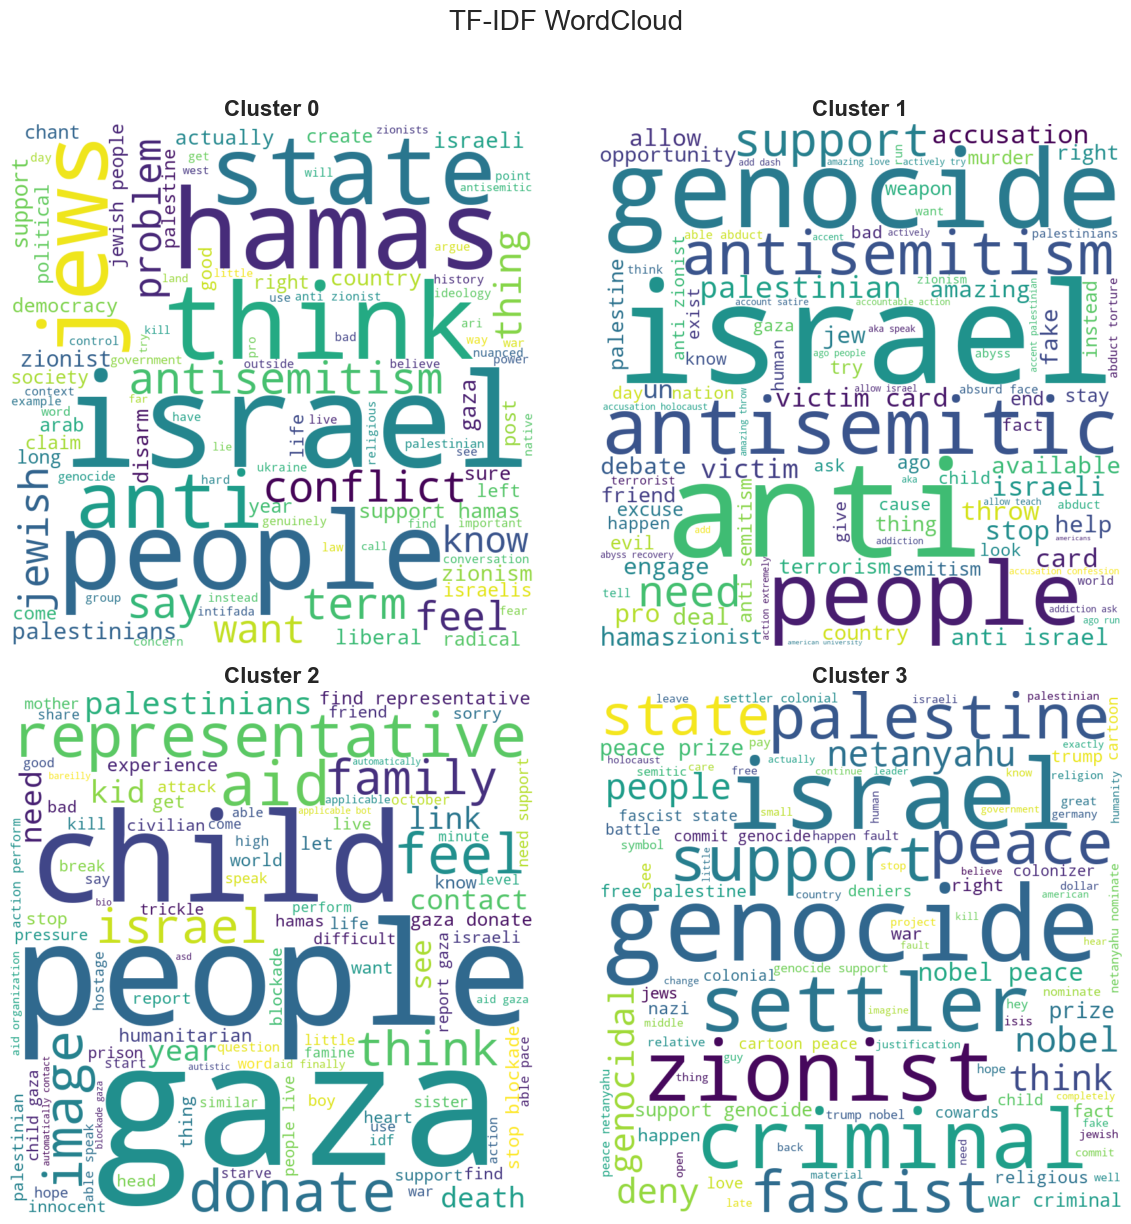

In [8]:
generate_cluster_tfidf_visualizations(
    processed_data,
    clust_label_col='clust_label_I',
    clust_object=clust_object_I,
    dist_matrix=D,
    results_dir=results_dir,
    knn_k=KNN_K_PLOTS,
    top_n=10,
    spacy_model="en_core_web_sm",
    custom_stopwords=['mean', 'like', 'go', 'to','lot', 'jewsofconscience'],
    batch_size=1000,
    bar_plot_name='optimal_clust_I_tf_idf_bar_plot.png',
    wordcloud_name='optimal_clust_I_tf_idf_wordcloud_plot.png'
)

In [36]:
medoid_and_knn_by_cluster = get_medoid_and_knn_by_cluster(clust_object_I, dist_matrix=D, knn_k=KNN_K_TEXTS)

for cluster_label in np.unique(clust_object_I.labels_):
        
    print('-'*50)
    print(f'Medoid and KNN for Cluster {cluster_label}:\n')
    print('-'*50)
    medoid_and_knn_data = processed_data[
        medoid_and_knn_by_cluster[cluster_label], 
        ['post_title', 'post_body', 'comment_body'] + CAT_COMPARISON_COLS
    ]
    file_name = f'medoid_and_knn_optimal_clust_I_{cluster_label}'
    parquet_file_name = f'{file_name}.parquet'
    csv_file_name = f'{file_name}.csv'
    parquet_save_path = os.path.join(results_dir, parquet_file_name)
    csv_save_path = os.path.join(results_dir, csv_file_name)
    medoid_and_knn_data.write_parquet(parquet_save_path)
    medoid_and_knn_data.write_csv(csv_save_path)
    
    display(medoid_and_knn_data)

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------


post_title,post_body,comment_body,political_stance_score_label,dominant_frame_score_label,discourse_tone_score_label,argument_quality_score_label,sentiment_score_label,post_subreddit
str,str,str,str,str,str,str,str,str
"""In NY (U.S.) pro-Israeli mob harassed a woman with ""Death to Arabs"" chants. Opinion?""","""Video can be found at another reddit post [here](https://www.reddit.com/r/WorldNewsHeadlines/comments/1kanko7/proisraeli_mob_harasses_woman_in_new_york_with/?utm_source=share&utm_medium=web3x&utm_name=web3xcss&utm_term=1&utm_content=share_button). A few questions on this shocking scene. Anyone knows who those extremists were? Why does American society (and Jewish community there) tolerate this kind of people? And a question for those pro-israelis who have problems with ""Free Palestine"" chants on pro-Palestinian demonstrations: do you have a problem with this ""**Death to Arabs**"" chant too or not really? Finally, imagine the opposite case, if the mob was pro-Palestinian harassing an israeli like that... pretty sure this subreddit would be burning in flames from anger and calling for those mobsters to be deported...""","""This behaviour is abhorrent. You can condemn this and still have a problem with the racist chants that come out of many pro-Palestine demonstrations. One does not cancel out the other. I’m not sure what point you’re trying to prove here. This is terrible AND there are many racist and violent things shouted about Israelis and Jews. By the way, the opposite case *did* happen when Arbel Yehud, who has held as a hostage in gaza for nearly 500 days, was nearly lynched by a violent massive mob of Palestinians.""","""Leaning Pro-Israel""","""Ideological""","""Analytical""","""Justified Opinion""","""Mildly Negative""","""IsraelPalestine"""
"""Largest Teachers' Union in United States Erases Jews From the Holocaust""","""https://freebeacon.com/america/largest-teachers-union-in-united-states-erases-jews-from-the-holocaust/ The nation's largest teachers' union plans to promote a version of Holocaust remembrance that does not mention Jews, according to its 2025 handbook, which references ""victims of the Holocaust from different faiths"" and teaches that Israel was founded through ""forced, violent displacement and dispossession,"" its most recent guide for members shows. ... The handbook says the union will ""promote the celebration of International Holocaust Remembrance Day"" by ""recognizing more than 12 million victims of the Holocaust from different faiths, ethnicities, races, political beliefs, genders, and gender identification, abilities/disabilities, and other targeted characteristics."" The description does not mention the attempted extermination of the Jewish people by the Nazis. ... The book does, however, give a lengthy description of its plans to ""educate members and the general public about the history of the Palestinian Nakba,"" while presenting a skewed version of Israel's founding that demonizes the Jewish state. ""Educating about the Nakba is essential for understanding the Palestinian diaspora narrative and experience, including the ongoing trauma of our Palestinian American students today. Teaching about the Nakba fosters critical thinking and empathy among students, promoting a deeper understanding of historical injustices and their contemporary ramifications."" """,""" The contemporary left, especially in the Anglophone world/United States, does not no where to place Jews in their cosmology. They see racism as bigotry plus power. If you are a victim of oppression or racism than this should manifest in terms of materially adverse outcomes and it should be systematic. In the English speaking countries Jews are generally seen as well educated, affluent, and not really suffering that much because they are Jews. Anti-Semitism doesn't make much sense in how it operates under this paradigm and they don't get it. A more sinister motive is that they see Israel and Zionism as illegitimate and the

--------------------------------------------------
Medoid and KNN for Cluster 1:

--------------------------------------------------


post_title,post_body,comment_body,political_stance_score_label,dominant_frame_score_label,discourse_tone_score_label,argument_quality_score_label,sentiment_score_label,post_subreddit
str,str,str,str,str,str,str,str,str
"""Queers for Palestine""","""Can someone explain to me how “ queers for Palestine” makes any sense. Israel is the only country in the Middle East that supports lgbtq people. There are actually massive pride parades there. Do people not get how it’s it is illegal to be queer in Palestine and how people can get killed for being gay there?? I’m going into my first year of university. I’m worried about going into the lgbtq spaces there because many people are pro Palestinian. The lgbtq club says that there should be no antisemitism but I highly doubt that’s the case because people can be antisemitic without knowing it. I wanted to take a course called women and gender studies but the syllabus says they are going to be reading books on Palestine. I’ve gone to a private Jewish school and now I’m going to be surrounded by many non Jews. ""","""People are stupid and uninformed. You can add a dash of antisemitism as well as""","""Strongly Pro-Israel""","""Ideological""","""Hostile""","""Pure Reaction""","""Moderately Negative""","""Israel"""
"""Can a pro-palestinian explain how they think Israel should have reacted on October 7th and in general to things its enemies do?""","""Pro-palestinians like to talk about how Israel is doing things the wrong way I would like to know what would they do if placed in Israel's position as I do honestly believe Israel is doing the best it possibly can given the circumstances I would like to know what you would do in Israel's position to make a two state solution or any other peace deal with a group that consistently and openly calls for your destruction and says there is no way they will agree to a two state solution (examples from the Hamas founding documents) >''The Islamic Resistance Movement believes that the land of Palestine is an Islamic Waqf consecrated for future Moslem generations until Judgement Day. It, or any part of it, should not be squandered: it, or any part of it, should not be given up."" ""Initiatives, and so-called peaceful solutions and international conferences, are in contradiction to the principles of the Islamic Resistance Movement"", ""\[I\]f the links have been distant from each other and if obstacles, placed by those who are the lackeys of Zionism in the way of the fighters obstructed the continuation of the struggle, the Islamic Resistance Movement aspires to the realisation of Allah's promise, no matter how long that should take. The Prophet, Allah bless him and grant him salvation, has said: ""The Day of Judgement will not come about until Muslims fight the Jews (killing the Jews), when the Jew will hide behind stones and trees. The stones and trees will say O Muslims, O Abdulla, there is a Jew behind me, come and kill him. Only the Gharkad tree, (evidently a certain kind of tree) would not do that because it is one of the trees of the Jews."" the last example is particularly interesting considering the complaint there is that the ""Zionists"" are stopping Hamas from completing their goal to kill all the Jews""","""I asked this once. I was told Israel 'should have apologized'. That was the day I realized the left had theorized itself into a moral abyss beyond recovery.""","""Strongly Pro-Israel""","""Ideological""","""Hostile""","""Pure Reaction""","""Moderately Negative""","""IsraelPalestine"""
"""The level of narcissism is off the charts""","""""","""""How dare you be anti-zionist when the weapons your police deploy against you are Israeli made""""","""Strongly Pro-Israel""","""Ideological""","""Hostile""","""Pure Reaction""","""Moderately Negative""","""Palestine"""
"""Event promotion Origin Sounds cancels Israeli DJ Roi Perez's show in London.""","""This comes after an article written by ""ravers""","""Not interested in learning from the Israeli side

--------------------------------------------------
Medoid and KNN for Cluster 2:

--------------------------------------------------


post_title,post_body,comment_body,political_stance_score_label,dominant_frame_score_label,discourse_tone_score_label,argument_quality_score_label,sentiment_score_label,post_subreddit
str,str,str,str,str,str,str,str,str
"""Do pro Palestine people think its alright for Israeli civilians to die?""","""Recently with the strikes on Israel i've seen a lot of pro Palestine people be happy about and even celebrate people dying and saying they deserve it and im just really curious where this attitude is coming from Personally,i live in Israel,and my stance on the conflict is pretty netural,i dont like the death in Palestine but i dont support hamas in any way.I think civilians dying is not good no matter what side it is A common excuse to wishing death of everyone in Israel is that they are all guilty by living on stolen land/being in the army,which is just wrong,no one chooses where they are born,and the army is mandatory,most people (like my mom for example ) are just trying to live their life and didn't even serve an active military role (like my mom being a secretary for example),and i dont think its ok for you to wish people like that death? What happened to being humane and not wanting people to die? Another common thing i've seen is people commenting stuff along the lines of ""the holocaust should happen again so the genocide in gaza would stop"" which is the most hypocritical thing i've read in my life,it feels like a lot of people on that side dont want people to stop dying full stop,they hust want the other side to die (which is the mentality a lot of governments supporters have here) I think this is also where a lot of the antisemitism accusations come from,criticizing the Israeli government isn't antisemitism,but calling for the death of civilians,which a lot dont support the actions of the country just because you think all of them are terrorist very much is?? People call this ""anti Zionist,not antisemetic"" but theres plenty of people here that aren't a Zionist yet i've seen people say we should just bomb Israel off the map if anyone here thinks me,a 15 year old that hasn't been in the army,doesn't support the government,and didn't choose to be born in ""occupied land"" i'd like to hear your reasoning for that.""","""Civilians and children should not be part of any conflict ever, however its getting REALLY hard to care when all I see is palestinian population centers getting bombed every day.""","""Leaning Pro-Palestine""","""Humanitarian""","""Emotional""","""Bare Opinion""","""Mildly Negative""","""IsraelPalestine"""
"""2 years of genocide""","""""","""The air and water are totally contaminated with cement and other toxic substances. A lot of people are going to get sick. Unfortunately a lot of kids are going to have respiratory issues.""","""Leaning Pro-Palestine""","""Humanitarian""","""Emotional""","""Bare Opinion""","""Mildly Negative""","""Palestine"""
"""Can a pro-palestinian explain how they think Israel should have reacted on October 7th and in general to things its enemies do?""","""Pro-palestinians like to talk about how Israel is doing things the wrong way I would like to know what would they do if placed in Israel's position as I do honestly believe Israel is doing the best it possibly can given the circumstances I would like to know what you would do in Israel's position to make a two state solution or any other peace deal with a group that consistently and openly calls for your destruction and says there is no way they will agree to a two state solution (examples from the Hamas founding documents) >''The Islamic Resistance Movement believes that the land of Palestine is an Islamic Waqf consecrated for future Moslem generations until Judgement Day. It, or any part of it, should not be squandered: it, or any part of it, should not be given up."" ""Initiatives, and so-called peaceful solutions and international conferences, are in contradiction to the principles of the Islamic Resistance Movement"", ""\[I\]f

--------------------------------------------------
Medoid and KNN for Cluster 3:

--------------------------------------------------


post_title,post_body,comment_body,political_stance_score_label,dominant_frame_score_label,discourse_tone_score_label,argument_quality_score_label,sentiment_score_label,post_subreddit
str,str,str,str,str,str,str,str,str
"""ISIS was added as an ally fighting besides Israel during the genocide on Gaza. More in the description.""","""This was added after Netenyahu publicly admitted that they were funding the ""Popular Forces"". As soon as it was up the Zionist propagandists were scrambling to get it removed from Wikipedia, instead they put the ""Popular Forces"" with Palestine flag next to them, now it looks like the second picture. When you click on popular forces you'll see their allegiance is to PA (bs) and to ISIS. They're still working tirelessly to remove any links to ISIS. You can check on the Wikipedia's edit history. However as well know, whatever is on the internet remains there forever. Ps: for anyone that says this is Wikipedia and anyone can edit it. True, but pages that are very controversial like this are usually locked and only verified users with a lot of experience are allowed to make edits, which then goes into revisions and get approved. There are people and bots that constantly monitor the slightest changes and revert them back within a second if they were deemed malicious or incorrect. You can try editing a very unimportant Wikipedia page for yourself and see how Link: (since it won't let me add Wikipedia for some reason) https://www.cbsnews.com/amp/news/israel-hamas-war-netanyahu-arming-gangs-gaza-clans-activated/""","""https://preview.redd.it/h8awt86zu76f1.jpeg?width=1283&format=pjpg&auto=webp&s=c4420df004af7f191c18ec2a9d9121ede02c39b0 Israel and ISIS are one and the same.""","""Strongly Pro-Palestine""","""Ideological""","""Hostile""","""Pure Reaction""","""Very Negative""","""Palestine"""
"""Piers Morgan has come so far on the issue of Gaza and Israel. My jaw is on the floor.""","""""","""""We would never do that."" ""It didn't happen."" ""It happens but not our fault."" ""It happens, but it's their fault and they deserve it.""""","""Strongly Pro-Palestine""","""Ideological""","""Hostile""","""Pure Reaction""","""Very Negative""","""Palestine"""
"""The UK has officially recognised Palestine""","""I have a lot to say on this, and it doesn’t change what’s happening on the ground, but as British-Palestinian I’m pleased with this development. This is huge. ""","""Hey Kier, you zionist prick, how about you actually protect the Palestinian people now?""","""Strongly Pro-Palestine""","""Ideological""","""Hostile""","""Pure Reaction""","""Very Negative""","""Palestine"""
"""~1,000 marched today near the Gaza border calling for an end to the starvation and war on Gaza""","""Marking Eid Al Adha, a relatively broad coalition of ~1,000 israeli jewish & palestinian left-wing and liberal activists led by the peace partnership and standing together marched along the Gaza border carrying food items and slogans against the war, against the starvation of gaza and calling for the return of the hostages. The food will be distributed in the west bank as aid cannot currently enter Gaza. It should be noted this was not an anti-zionist event but it marks a shift of a significant part of liberal israeli sentiment with regards to the war and genocide in Gaza. I designed and created the flag you see in the video, which reads ""No to starvation"". In the distance, plumes of smoke and fog envelop the northern Gaza strip. Once every few minutes, we heard an explosion and a strong smell of gunpowder lingered in the area. I wish more of us woke up from our complicity but I firmly believe this will not happen without foreign pressure. The labour aristocracy is all too comfortable holding its zionist worldview so long as there is material ground to maintain it.""","""""See, we're a democracy!"" -Zionists after they couldn't suppress each and every protest. Those people should leave, divest themselves from, and revoke their citizenship wit

## Clustering II: SampleDistClustering-KMedoids-PAM - k=4

c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


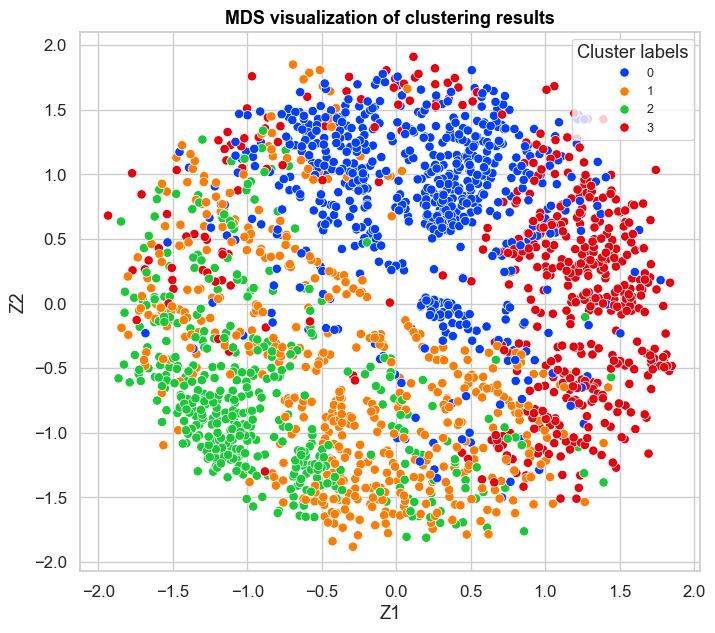

In [37]:
D, D1, D2, D3 = clust_object_II.dist_output
sample_idx = clust_object_II.sample_idx

plot_file_name = 'optimal_clust_II_mds_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

if not os.path.exists(plot_save_path):

    n_reduced = 2000

    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=123) 

    X_mds = mds.fit_transform(D[:n_reduced, :n_reduced])

    clustering_MDS_plot_one_method(X_mds=X_mds, 
                                y_pred=clust_labels_II[sample_idx[:n_reduced]], 
                                y_true=None, title="MDS visualization of clustering results", 
                                accuracy=None, time=None, 
                                figsize=(8,7), bbox_to_anchor=(1,1), 
                                title_size=13, title_weight='bold', 
                                points_size=45, title_height=1, legend_size=9,
                                save=True, file_name=plot_save_path, format='png'
    )

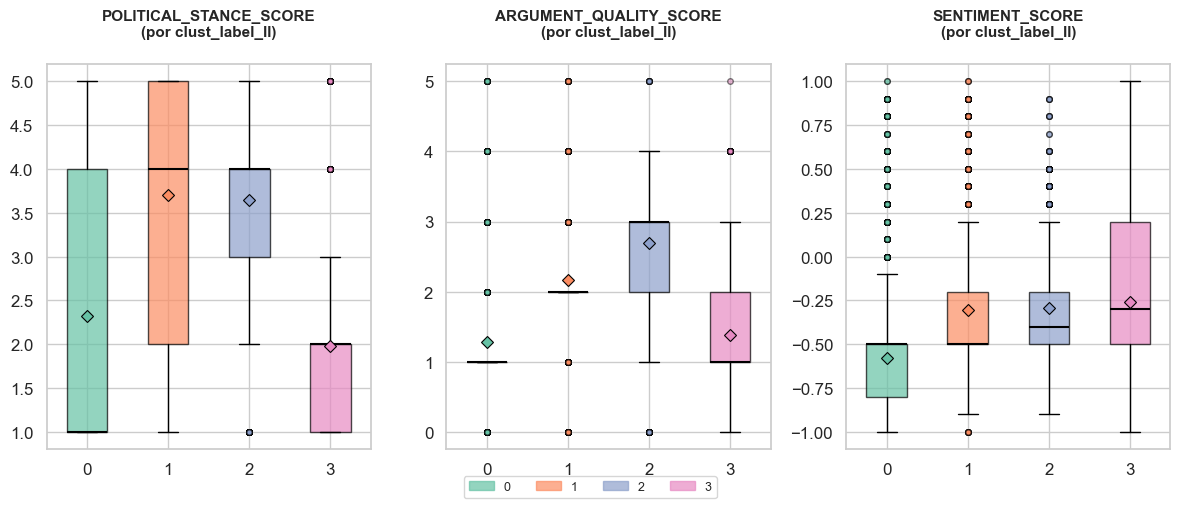

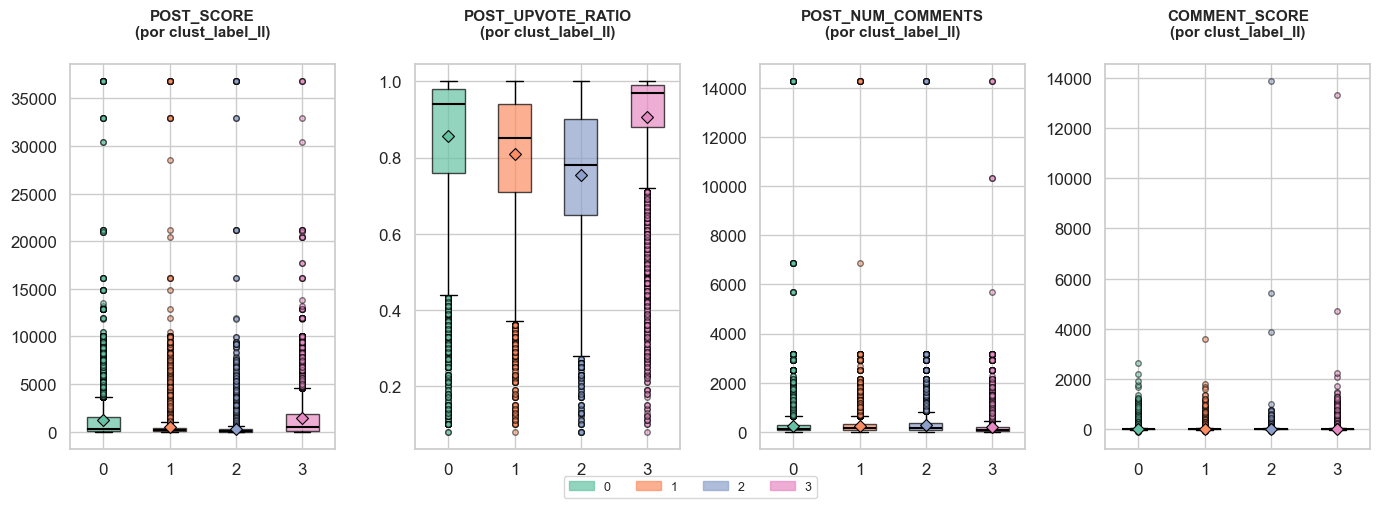

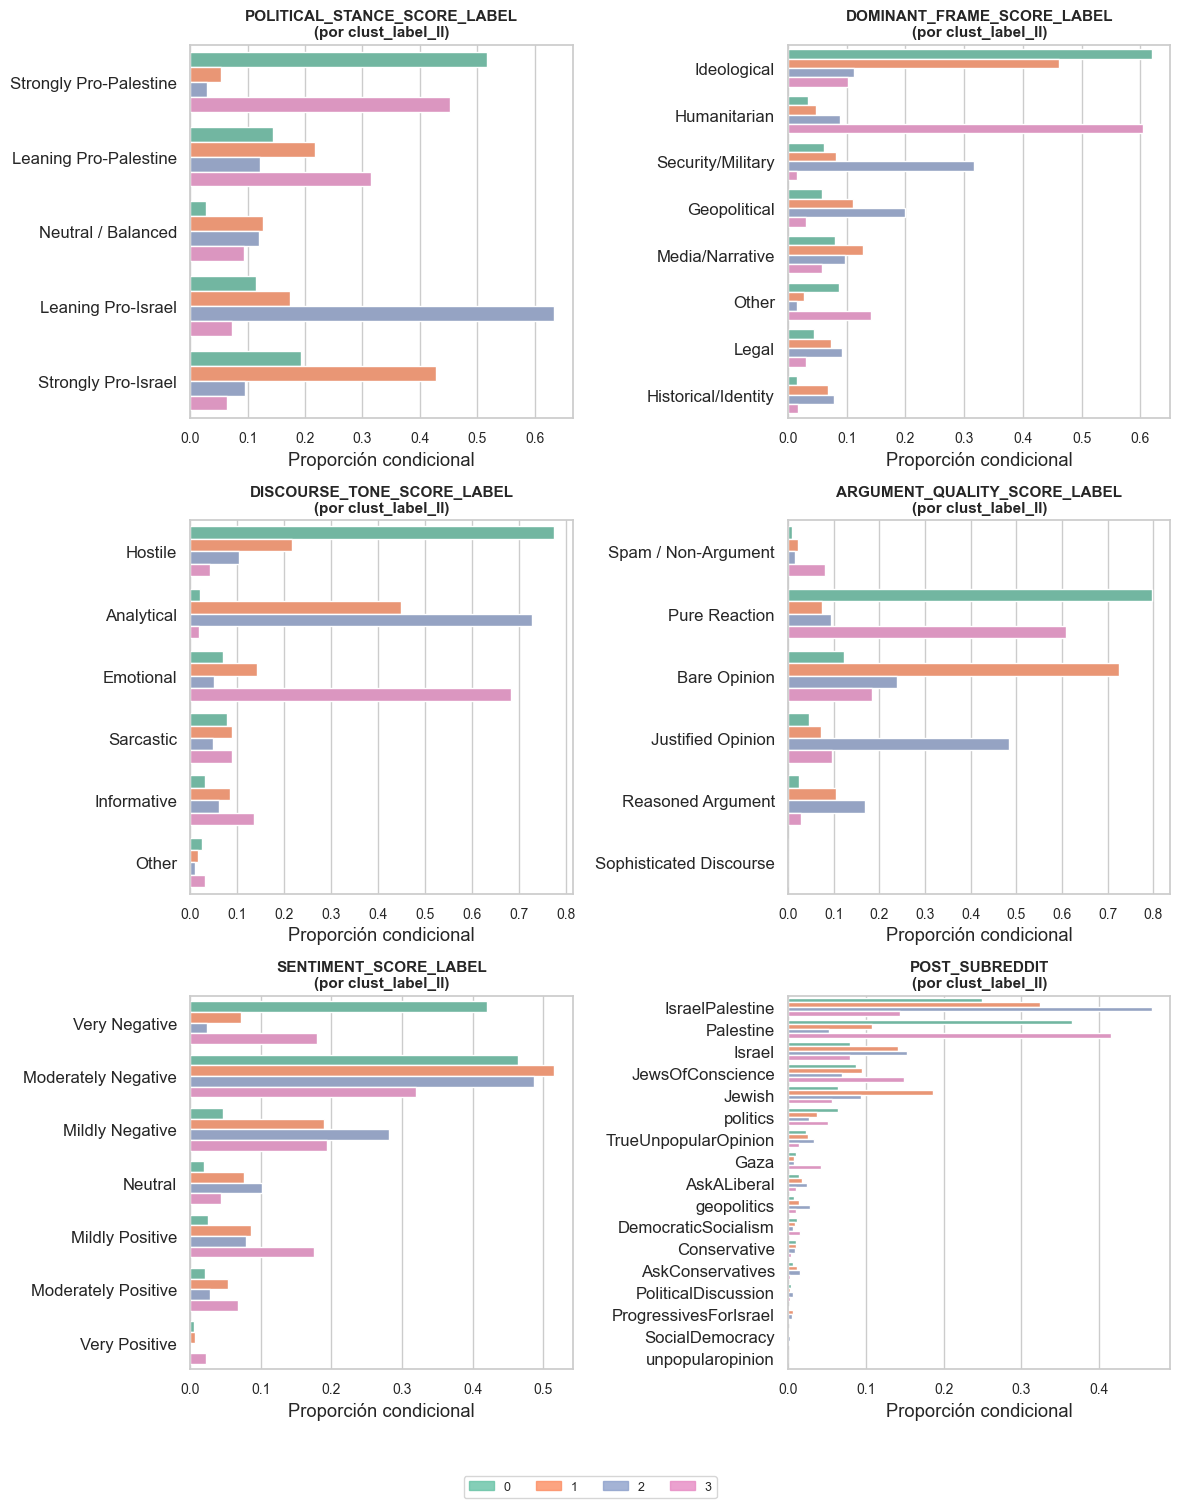

In [44]:
##################################################################################################

plot_file_name = 'optimal_clust_II_quant_discursive_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_quant_comparison(
    figsize=(12, 5),
    df=processed_data,
    comparisons=[
        [col] for col in QUANT_DISCURSIVE_COMPARISON_COLS
    ],
    group_by="clust_label_II",
    showfliers=True,
    title='',
    labelbottom=True,
    xlabel_rotation=0,
    bbox_to_anchor=(0.5, -0.03),
    save_path = plot_save_path
    
)

##################################################################################################

plot_file_name = 'optimal_clust_II_quant_reddit_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_quant_comparison(
    figsize=(14, 5),
    df=processed_data,
    comparisons=[
        [col] for col in QUANT_REDDIT_COMPARISON_COLS
    ],
    group_by="clust_label_II",
    showfliers=True,
    title='',
    labelbottom=True,
    xlabel_rotation=0,
    bbox_to_anchor=(0.5, -0.03),
    save_path = plot_save_path,
    max_cols=4,
)

##################################################################################################

plot_file_name = 'optimal_clust_II_cat_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_cat_comparison(
    df=processed_data, 
    comparisons=[
        [col] for col in CAT_COMPARISON_COLS 
    ], 
    title="",
    bbox_to_anchor=(0.5,-0.01),
    group_by="clust_label_II",
    max_cols=2,
    x_rotation=0,
    orientation='h',
    order=CAT_COMPARISON_ORDER,
    save_path = plot_save_path
)

##################################################################################################

Filtrando dataset mediante índices de medoids y KNN...
Lematizando exclusivamente los comentarios filtrados...
Agrupando comentarios por cluster...
Generando Gráfico de Barras SOTA...


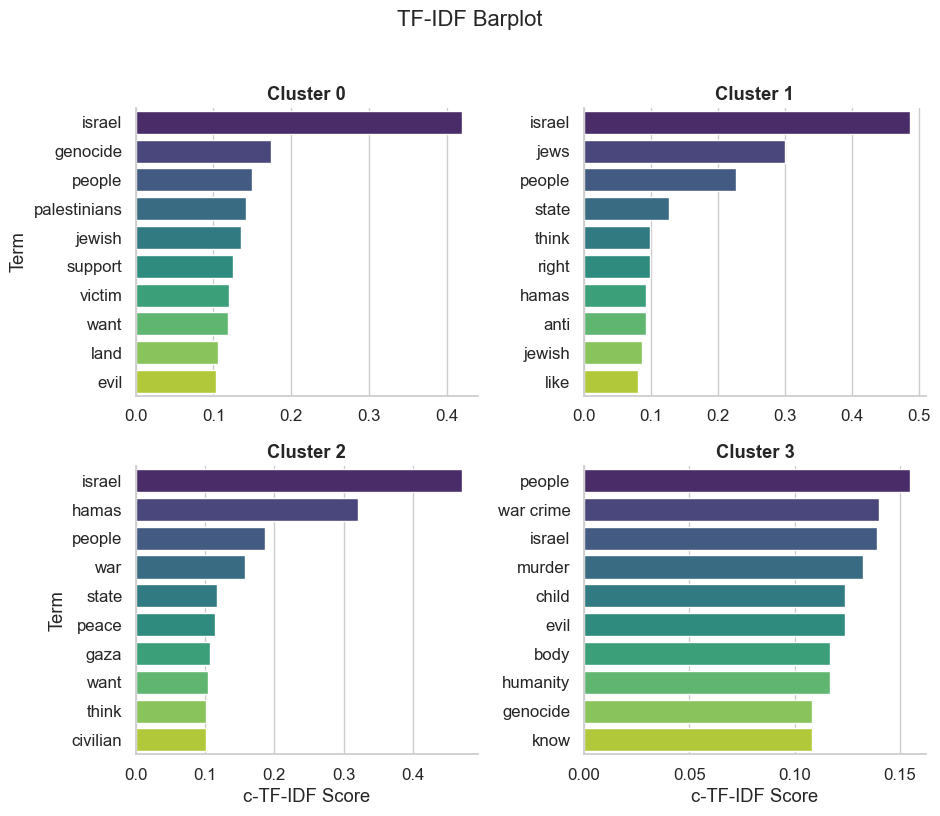

Generando Nubes de Palabras basadas en pesos c-TF-IDF...


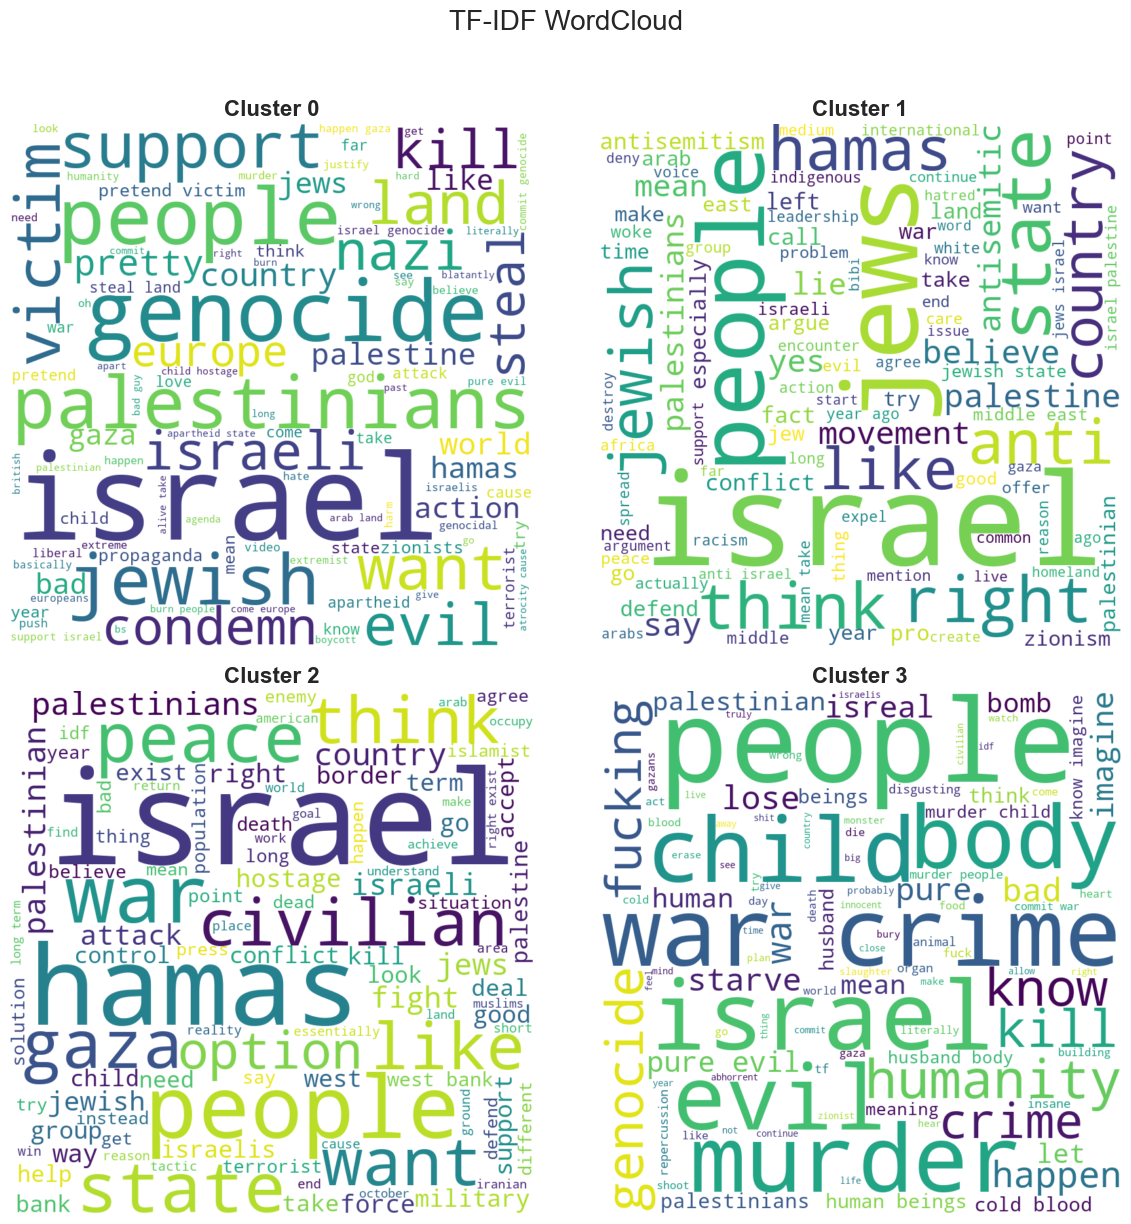

In [39]:
generate_cluster_tfidf_visualizations(
    data=processed_data,
    clust_label_col='clust_label_II',
    clust_object=clust_object_II,
    dist_matrix=D,
    results_dir=results_dir,
    knn_k=KNN_K_PLOTS,
    top_n=10,
    spacy_model="en_core_web_sm",
    batch_size=1000,
    bar_plot_name='optimal_clust_II_tf_idf_bar_plot.png',
    wordcloud_name='optimal_clust_II_tf_idf_wordcloud_plot.png'
)

In [40]:
medoid_and_knn_by_cluster = get_medoid_and_knn_by_cluster(clust_object_II, dist_matrix=D, knn_k=KNN_K_TEXTS)

for cluster_label in np.unique(clust_object_I.labels_):
        
    print('-'*50)
    print(f'Medoid and KNN for Cluster {cluster_label}:\n')
    print('-'*50)
    medoid_and_knn_data = processed_data[
        medoid_and_knn_by_cluster[cluster_label], 
        ['post_title', 'post_body', 'comment_body'] + CAT_COMPARISON_COLS
    ]
    file_name = f'medoid_and_knn_optimal_clust_II_{cluster_label}'
    parquet_file_name = f'{file_name}.parquet'
    csv_file_name = f'{file_name}.csv'
    parquet_save_path = os.path.join(results_dir, parquet_file_name)
    csv_save_path = os.path.join(results_dir, csv_file_name)
    medoid_and_knn_data.write_parquet(parquet_save_path)
    medoid_and_knn_data.write_csv(csv_save_path)
    
    display(medoid_and_knn_data)

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------


shape: (11, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ post_titl ┆ post_body ┆ comment_b ┆ political ┆ … ┆ discourse ┆ argument_ ┆ sentiment ┆ post_sub │
│ e         ┆ ---       ┆ ody       ┆ _stance_s ┆   ┆ _tone_sco ┆ quality_s ┆ _score_la ┆ reddit   │
│ ---       ┆ str       ┆ ---       ┆ core_labe ┆   ┆ re_label  ┆ core_labe ┆ bel       ┆ ---      │
│ str       ┆           ┆ str       ┆ l         ┆   ┆ ---       ┆ l         ┆ ---       ┆ str      │
│           ┆           ┆           ┆ ---       ┆   ┆ str       ┆ ---       ┆ str       ┆          │
│           ┆           ┆           ┆ str       ┆   ┆           ┆ str       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ If Pro-Pa ┆ This is   ┆ Israel IS ┆ Strongly  ┆ … ┆ Hostile   ┆ Pure      ┆ Very      ┆ IsraelPa │
│ lestine   ┆ an honest ┆ THE BAD   ┆ Pro-Pales ┆   ┆           ┆ Reaction  ┆ Negative  ┆ lestine  │
│ “empathy” ┆ to god    ┆ GUY. Why  ┆ tine      ┆   ┆           ┆           ┆           ┆          │
│ leads to  ┆ question  ┆ you ask?  ┆           ┆   ┆           ┆           ┆           ┆          │
│ more      ┆ as I      ┆ 70,000    ┆           ┆   ┆           ┆           ┆           ┆          │
│ deaths,   ┆ genuinely ┆ killed by ┆           ┆   ┆           ┆           ┆           ┆          │
│ what are  ┆ do not    ┆ Israel in ┆           ┆   ┆           ┆           ┆           ┆          │
│ we        ┆ understan ┆ response  ┆           ┆   ┆           ┆           ┆           ┆          │
│ actually  ┆ d how     ┆ to an     ┆           ┆   ┆           ┆           ┆           ┆          │
│ supportin ┆ people    ┆ attack.   ┆           ┆   ┆           ┆           ┆           ┆          │
│ g?        ┆ can look  ┆ Lands     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ at this   ┆ stolen    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ conflict  ┆ and       ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ and       ┆ continue  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ conclude  ┆ to be     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ that      ┆ stolen    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ Israel is ┆ from Pale ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ “the bad  ┆ stinians  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ guy.” The ┆ in the    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ war       ┆ West      ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ itself is ┆ Bank.     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ tragic    ┆ Simple.   ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ and       ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ nobody    ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ with a    ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ sense of  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ humanity  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ celebrate ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ s it, but ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ when you  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ look at   ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ the last  ┆           ┆         

--------------------------------------------------
Medoid and KNN for Cluster 1:

--------------------------------------------------


post_title,post_body,comment_body,political_stance_score_label,dominant_frame_score_label,discourse_tone_score_label,argument_quality_score_label,sentiment_score_label,post_subreddit
str,str,str,str,str,str,str,str,str
"""Saw someone on Reddit say “Israel is genuinely a sociopathic society” and I am disgusted""","""I was lurking on a Reddit thread and saw someone say that “Israel is genuinely a sociopathic society.” It hit me like a punch to the gut. Calling an entire society sociopathic? This is blatant antisemitism. As if there’s not a single Israeli citizen who doesn’t protest the current government? As if there’s no dissent, no nuance, no humanity? What they’re saying is “all Israelis are sociopaths “ which then means that all Jews are sociopaths. I’m Jewish. I’ve always considered myself on the left, but I’ve been feeling increasingly alienated. It’s exhausting to constantly see dehumanizing rhetoric, to watch people who claim to care about justice repeat antisemitic talking points, and to be told directly or indirectly that my life, my people, my pain don’t matter. I’m so sick and tired of antisemitism becoming normal. ""","""Most of them are misinformed about the Israel/Palestine conflict. They believe Palestinians are indigenous to the area. They believe Jews stole the land that is now Israel. They believe the U.S. armed Israel in her war for independence. They believe Israel is a theocracy. They believe the West Bank is on the west side of Palestine, and that's why it's called the ""west bank."" They believe that Israel was gifted to the Jews by the U.N. They lie about Israel and Palestinians for the same reason conservatives lie to defend Trump and the GOP. They lie because they can't defend their opinions using facts and logic.""","""Strongly Pro-Israel""","""Ideological""","""Analytical""","""Bare Opinion""","""Mildly Negative""","""Jewish"""
"""Feeling really disturbed at the current Israel discourse on Reddit""","""I’m sure many of you have already gotten to this point way before the most recent incident with Israel and Iran but I’ve just been gobsmacked at how the overwhelming majority of Reddit is just straight up pro Iran getting nukes/anti Israel and gleeful in the paradigm that “Israel deserved it and anything that happens to them” based off the issues in Gaza. I feel like I’m taking crazy pills where no one is aware of the entire history of this conflict and why Israel operates the way it does with it’s preventative attacks. I can’t tell if it’s a genuine hatred of Israel, an ignorance of history, remnants of all the anti Israel misinformation and brainwashing shoved at Gen Z through avenues such as TikTok. I go over to the conservative subreddit and somehow they are the only ones thinking logically about this situation amidst all their lunacy. I feel so lost as a liberal jew Zionist. I can’t tell what’s up or down anymore, it really feels like this site is starting to go down the deep end. EDIT: I know a lot of you are saying its just bots, but the point is that what started as bots has now transitioned to normal real people with these views. Just last night someone in SF was assaulted for confronting a bunch of drunk guys shouting ""fuck jews"". Anti-zionism and anti-semitism is becoming mainstream on reddit and mainstream IRL. https://www.sfchronicle.com/crime/article/man-assaulted-friend-decries-attack-as-antisemitic-20378435.php""","""It’s just basic Jew hatred, same as what our grandparents faced. Just slightly repackaged. Why do I think this? Because in their minds children in Gaza and Iran are innocent, yet Jewish children in Israel are somehow tainted at birth. Collective punishment is wrong, except for when it comes to Jews and Israelis. They condemn the KKK yet repeat their tropes (“Zio”). Etc. There’s no logic to it. It’s just pure Jew hatred. ""","""Strongly Pro-Israel""","""Ideological""","""Hostile""","""Bare Opinion""","""Very Negative""","""Jewish"""
"""Feeling really disturbed at the curre

--------------------------------------------------
Medoid and KNN for Cluster 2:

--------------------------------------------------


shape: (11, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ post_titl ┆ post_body ┆ comment_b ┆ political ┆ … ┆ discourse ┆ argument_ ┆ sentiment ┆ post_sub │
│ e         ┆ ---       ┆ ody       ┆ _stance_s ┆   ┆ _tone_sco ┆ quality_s ┆ _score_la ┆ reddit   │
│ ---       ┆ str       ┆ ---       ┆ core_labe ┆   ┆ re_label  ┆ core_labe ┆ bel       ┆ ---      │
│ str       ┆           ┆ str       ┆ l         ┆   ┆ ---       ┆ l         ┆ ---       ┆ str      │
│           ┆           ┆           ┆ ---       ┆   ┆ str       ┆ ---       ┆ str       ┆          │
│           ┆           ┆           ┆ str       ┆   ┆           ┆ str       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ If Pro-Pa ┆ This is   ┆ I agree,  ┆ Leaning   ┆ … ┆ Analytica ┆ Justified ┆ Mildly    ┆ IsraelPa │
│ lestine   ┆ an honest ┆ which is  ┆ Pro-Israe ┆   ┆ l         ┆ Opinion   ┆ Negative  ┆ lestine  │
│ “empathy” ┆ to god    ┆ why while ┆ l         ┆   ┆           ┆           ┆           ┆          │
│ leads to  ┆ question  ┆ I say     ┆           ┆   ┆           ┆           ┆           ┆          │
│ more      ┆ as I      ┆ that I’m  ┆           ┆   ┆           ┆           ┆           ┆          │
│ deaths,   ┆ genuinely ┆ pro-Pales ┆           ┆   ┆           ┆           ┆           ┆          │
│ what are  ┆ do not    ┆ tine at   ┆           ┆   ┆           ┆           ┆           ┆          │
│ we        ┆ understan ┆ this      ┆           ┆   ┆           ┆           ┆           ┆          │
│ actually  ┆ d how     ┆ point of  ┆           ┆   ┆           ┆           ┆           ┆          │
│ supportin ┆ people    ┆ the war   ┆           ┆   ┆           ┆           ┆           ┆          │
│ g?        ┆ can look  ┆ because I ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ at this   ┆ think     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ conflict  ┆ Israel    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ and       ┆ needs to  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ conclude  ┆ be restra ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ that      ┆ ined, so  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ Israel is ┆ there is  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ “the bad  ┆ an        ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ guy.” The ┆ incentive ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ war       ┆ to end    ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ itself is ┆ the war,  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ tragic    ┆ I’ll      ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ and       ┆ never be  ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ nobody    ┆ an anti-Z ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ with a    ┆ ionist. I ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ sense of  ┆ think the ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ humanity  ┆ fears     ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ celebrate ┆ that      ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ s it, but ┆ Israeli   ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ when you  ┆ Jews have ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ look at   ┆ against   ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ the last  ┆ their     ┆         

--------------------------------------------------
Medoid and KNN for Cluster 3:

--------------------------------------------------


post_title,post_body,comment_body,political_stance_score_label,dominant_frame_score_label,discourse_tone_score_label,argument_quality_score_label,sentiment_score_label,post_subreddit
str,str,str,str,str,str,str,str,str
"""The most disturbing story you'll hear today: Israel killed the family of a Gaza surgeon, Dr. Khalid, forcing him to watch it live.""","""Source in the comments. ""","""This is the shit their doing that we know about. Imagine what theure doing that we don't know about.""","""Strongly Pro-Palestine""","""Humanitarian""","""Emotional""","""Pure Reaction""","""Moderately Negative""","""Palestine"""
"""Israel used US-supplied thermal Weapons that burn at 3,500C to Murder thousands of Palestinians, the people evaporated.""","""""","""They no longer want bodies to be the only witness to their atrocities, what is happening? How can we let this go on?""","""Strongly Pro-Palestine""","""Humanitarian""","""Emotional""","""Pure Reaction""","""Moderately Negative""","""Gaza"""
"""This is how a normal day in Gaza looks like""","""""","""Israel bombs and murders people in brutally violent ways, then tries to justify it afterwards by claiming they were ‘acting.’ It’s sick and evil.""","""Strongly Pro-Palestine""","""Humanitarian""","""Emotional""","""Pure Reaction""","""Very Negative""","""Palestine"""
"""The IDF has been carrying out this depraved stunt to lure and kill Palestinians since April last year...""","""""","""At this point they are trying to be the most evil people on earth. I mean the abuse they are trying to exert on Palestinians has passed the holocaust in cruelty. They are playing with Gaza’s before they kill them and it’s all for their own pleasure. And this only based on what we know, imagine what we will learn when this is all over.""","""Strongly Pro-Palestine""","""Humanitarian""","""Emotional""","""Pure Reaction""","""Very Negative""","""Palestine"""
"""The Gaza holocaust""","""""","""They're purposefully AIMING for children https://youtu.be/U5k_Sw_UNpo?si=JXtUCDIyAsWiAwHX The plan for Isreal is to murder the children in order to prevent the Gazans from reproducing. Trully despicable""","""Strongly Pro-Palestine""","""Humanitarian""","""Emotional""","""Pure Reaction""","""Very Negative""","""Palestine"""
…,…,…,…,…,…,…,…,…
"""Israel is killing 100 Palestinians every day and the mainstream media barely reports it. They’ve normalized daily massacres.""","""""","""Plus there are a bunch of hasbaraists right now reporting that gazans are soooo thankful for food that they are been given by the US, as if they haven't been bombed and starved and burying their children because of them. I really had it with humans.""","""Strongly Pro-Palestine""","""Humanitarian""","""Emotional""","""Pure Reaction""","""Very Negative""","""Palestine"""
"""'It's a Killing Field': IDF Soldiers Ordered to Shoot Deliberately at Unarmed Gazans Waiting for Humanitarian Aid""","""Haaretz Exposé IDF Soldiers Ordered to Target Unarmed Civilians in Gaza Proof of Systematic Killing https://archive.is/20250627130556/https://www.haaretz.com/israel-news/2025-06-27/ty-article-magazine/.premium/idf-soldiers-ordered-to-shoot-deliberately-at-unarmed-gazans-waiting-for-humanitarian-aid/00000197-ad8e-de01-a39f-ffbe33780000 A bombshell Haaretz investigation reveals Israeli soldiers admitting they were ordered to deliberately shoot unarmed Palestinians at Gaza aid sites even when crowds posed zero threat. Testimonies describe a killing field where 1 to 5 civilians were gunned down daily using heavy machine guns mortars and tank fire instead of non lethal crowd control. One soldier bluntly stated We communicate with them through fire. The report exposes a chilling normalization of slaughter commanders labeled the operation Salted Fish a twisted reference to a children’s game while a senior officer admitted They were just killed for nothing. Over 549 Palestinians have been killed near aid centers since May with 4000 plus wounded most shot while scrambli

## Clustering III: Kmeans - k=4

c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


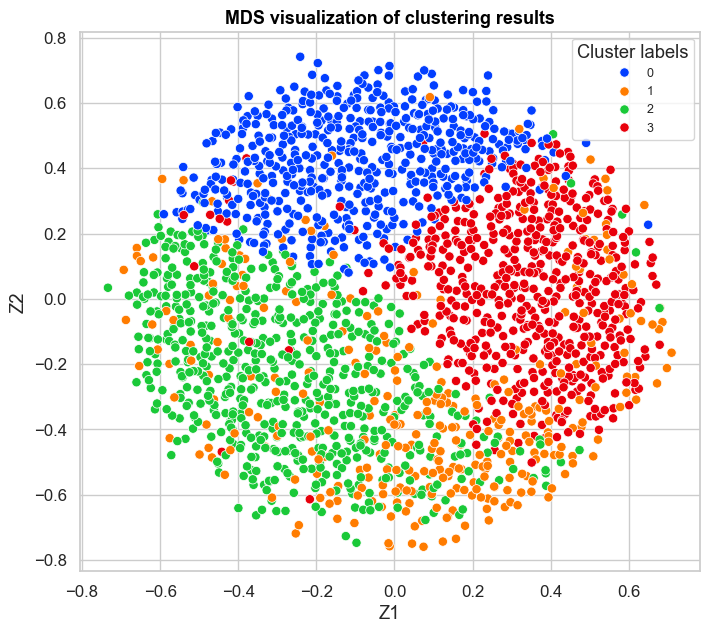

In [41]:
plot_file_name = 'optimal_clust_III_mds_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

n_reduced = 2000

embeddings_cols = [col for col in processed_data.columns if 'embedding' in col]
X = processed_data[embeddings_cols]
D = euclidean_dist_matrix(X[:n_reduced,:])

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=123) 

X_mds = mds.fit_transform(D[:n_reduced, :n_reduced])

clustering_MDS_plot_one_method(X_mds=X_mds, 
                            y_pred=clust_labels_III[:n_reduced], 
                            y_true=None, title="MDS visualization of clustering results", 
                            accuracy=None, time=None, 
                            figsize=(8,7), bbox_to_anchor=(1,1), 
                            title_size=13, title_weight='bold', 
                            points_size=45, title_height=1, 
                                save=True, file_name=plot_save_path, format='png'
)

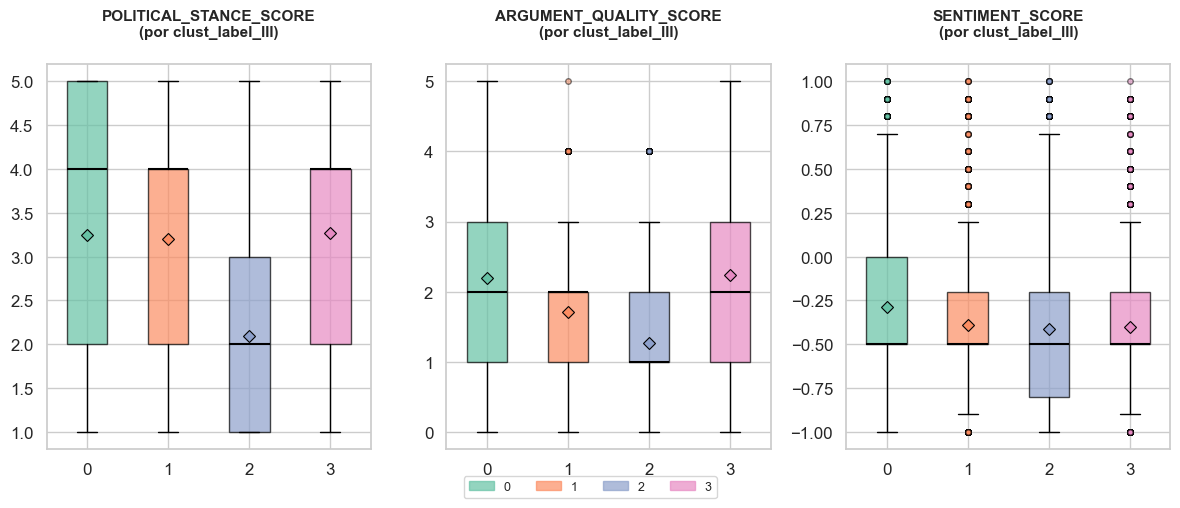

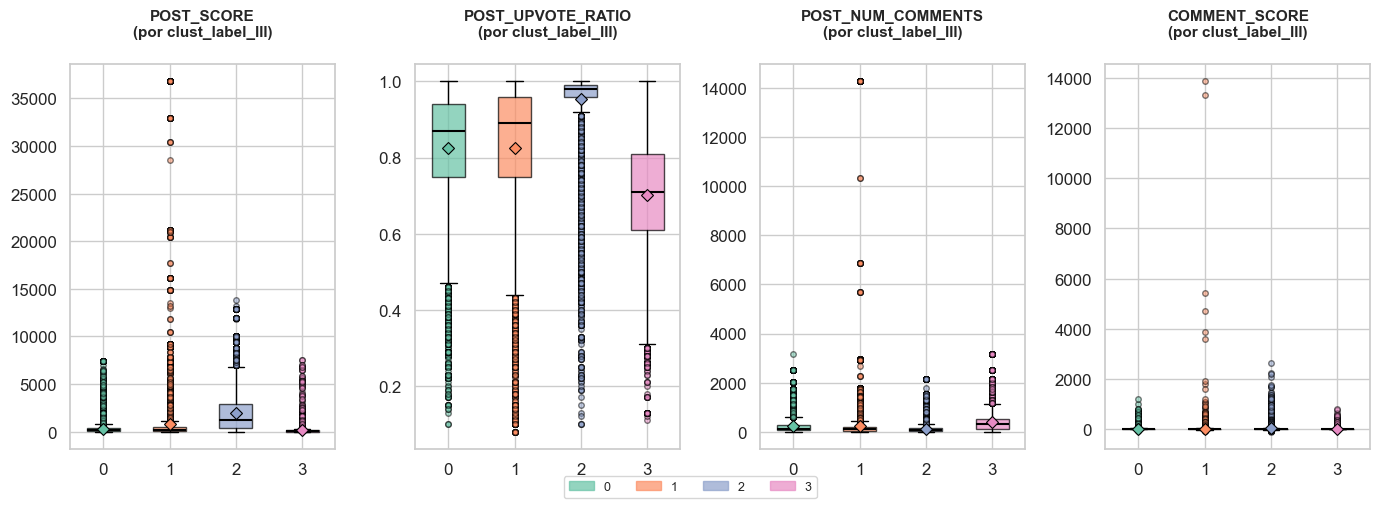

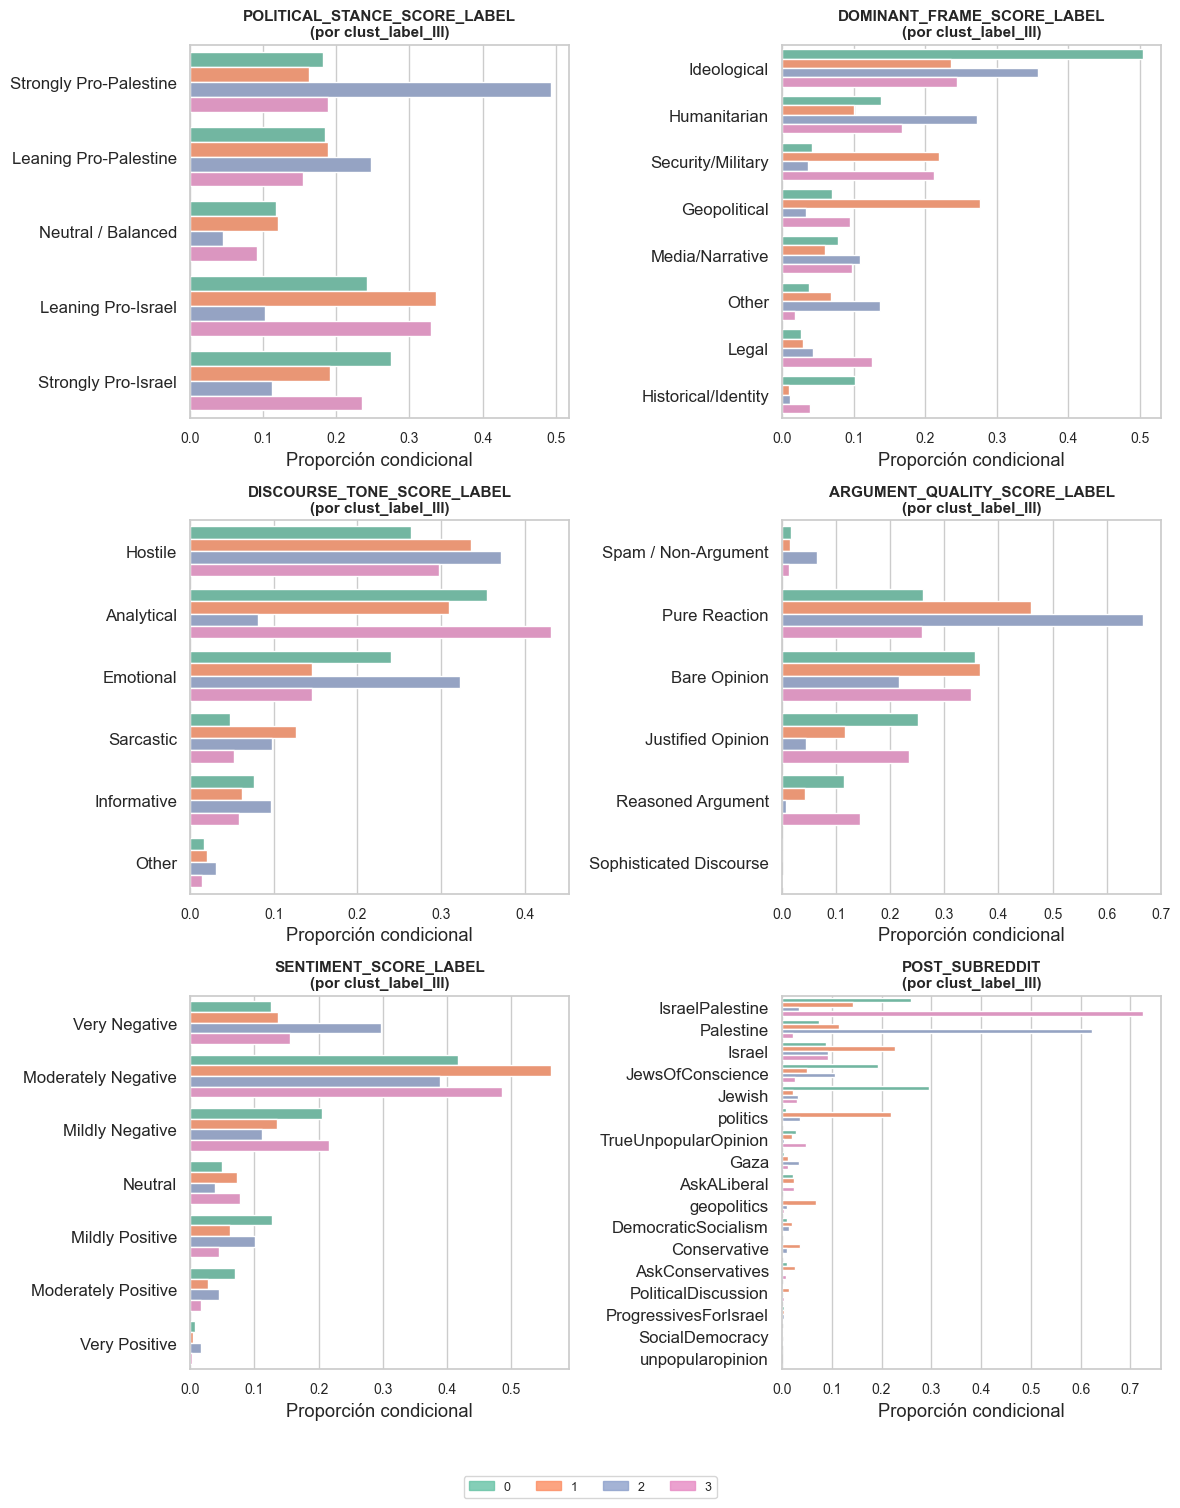

In [43]:
##################################################################################################

plot_file_name = 'optimal_clust_III_quant_discursive_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_quant_comparison(
    figsize=(12, 5),
    df=processed_data,
    comparisons=[
        [col] for col in QUANT_DISCURSIVE_COMPARISON_COLS
    ],
    group_by="clust_label_III",
    showfliers=True,
    title='',
    labelbottom=True,
    xlabel_rotation=0,
    bbox_to_anchor=(0.5, -0.03),
    save_path = plot_save_path
    
)

##################################################################################################

plot_file_name = 'optimal_clust_III_quant_reddit_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_quant_comparison(
    figsize=(14, 5),
    df=processed_data,
    comparisons=[
        [col] for col in QUANT_REDDIT_COMPARISON_COLS
    ],
    group_by="clust_label_III",
    showfliers=True,
    title='',
    labelbottom=True,
    xlabel_rotation=0,
    bbox_to_anchor=(0.5, -0.03),
    save_path = plot_save_path,
    max_cols=4,
)

##################################################################################################

plot_file_name = 'optimal_clust_III_cat_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_cat_comparison(
    df=processed_data, 
    comparisons=[
        [col] for col in CAT_COMPARISON_COLS 
    ], 
    title="",
    bbox_to_anchor=(0.5,-0.01),
    group_by="clust_label_III",
    max_cols=2,
    x_rotation=0,
    orientation='h',
    order=CAT_COMPARISON_ORDER,
    save_path = plot_save_path
)

##################################################################################################